In [3]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

words = open('names.txt', 'r').read().splitlines()

# Lecture 4 (Makemore pt 3): Notes on MLP internals: Activations, Gradients, BatchNorm

In [49]:
# change log

# fix softmax was confidently wrong by initializing to more uniform (maximal entropy) distribution (want values near zero)
        # can know our expected initial loss with -log(1/27) because 27 character alphabet

# fix tanh layer too saturated at initialization
        # want h to be near zero so that tanh doesnt saturate too much
        # if most tanh(hpreact) ~ -1 or 1, then grad of tanh ~ 0, --> dead neuron

# as you multiply guassians together, the standard deviations increase (guassian noise propogates). thus you need to scale it by gain / sqrt(sample size)
# common way to initialize a neural net for this is: torch.nn.init.kaiming_normal_
# often just scale by 1 / sqrt(fan_in), fan_in = number of layer inputs

# batch normalization 
# Paper: Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift 
# https://arxiv.org/pdf/1502.03167
        # for reasons discussed above, we want the hidden layer (pre-activation) to be roughly guassian with mean 0 and sd 1 at initialization
        # thus we simply normalize the layer (on the training batch) so that it is
        # this is okay because normalization is a differential operation so its fine for back-prop
        # note that we want the layer to be roughly guassian at initialization, but not forced to be at all steps
        # thus implement scale and shift
        # ...what if the same issue with grad = 0 occurs later in the loop...?
        # important note about consequence at around 51-52 min of vid 4:
                # examples in the batch are mathematically coupled in the forward pass because (?) hidden layer is now a function of the batch statistics (thus of other randomly selected examples)
        # but this acts as a regularizer too
        # other normalization methods that do not have this effect: layer normalization, instance normalization, group normalization
        
# ResNet is standard example of a Residual Neural Network

# when we train on a randomly sampled batch rather than the entire training set, our optimizer would be called Stochastic Gradient Descent

In [5]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)


In [6]:
# Built dataset
block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] 
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) # training set 80%
Xdev, Ydev = build_dataset(words[n1:n2]) # dev set 10%
Xte, Yte = build_dataset(words[n2:]) # test set 10%


In [7]:
# Construct and Initialize MLP
n_embd = 10 # the dimensionality of the character embedding vectors (latent space dimension I believe)
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),               generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden),   generator=g) * (5/3) / ((n_embd * block_size)**0.5)
#b1 = torch.randn(n_hidden,                          generator=g) * 0.01 # if using batch normalization with scale and shift, bias is removed when mean is subtracted so dont use it
W2 = torch.randn((n_hidden, vocab_size),            generator=g) * 0.01
b2 = torch.randn(vocab_size,                        generator=g) * 0

# scale and shift for batch normalization output
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # total number of parameters in model
for p in parameters:
    p.requires_grad = True

12097


In [8]:
# Gradient Descent
max_steps = 200000
batch_size = 32
lossi = []


for i in range(max_steps):
    
    # minibatch construction (for computational speed)
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g) # samples 32 indexes from dataset
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y
    
    # forward pass
    emb = C[Xb] # embed the chars into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # batch normalization
    
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer (log counts)
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update parameters
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
    # track states
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d} : {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000 : 3.3239
  10000/ 200000 : 2.0322
  20000/ 200000 : 2.5675
  30000/ 200000 : 2.0125
  40000/ 200000 : 2.2446
  50000/ 200000 : 1.8897
  60000/ 200000 : 2.0785
  70000/ 200000 : 2.3681
  80000/ 200000 : 2.2918
  90000/ 200000 : 2.0238
 100000/ 200000 : 2.3673
 110000/ 200000 : 2.3132
 120000/ 200000 : 1.6414
 130000/ 200000 : 1.9311
 140000/ 200000 : 2.2231
 150000/ 200000 : 2.0027
 160000/ 200000 : 2.0997
 170000/ 200000 : 2.4949
 180000/ 200000 : 2.0198
 190000/ 200000 : 2.1707


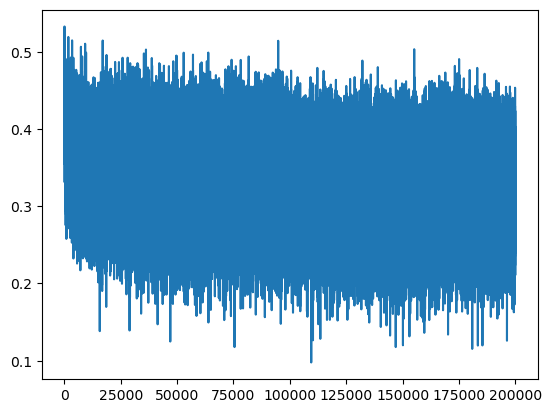

In [9]:
plt.plot(lossi)

In [10]:
# want to be able to feed in a single example to the model and get a prediction out
# but now the model expects a batch as an input because it needs the batch mean and std

# calibrate the batch norm at the end of training
# this is the explicit calculation of these stats
# we will see that the running estimation calculation of these stats matches this pretty well, which is easier because it runs in parallel with model training
# so dont need this code:

with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 #+ b1
    # measure the mean and std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

In [11]:
@torch.no_grad() # this decorator disables gradient tracking (just for efficiency)
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev), # validation (development)
        'test': (Xte, Yte)
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 #+ b1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias # batch normalization
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())
    
split_loss('train')
split_loss('val')

train 2.0674145221710205
val 2.1056838035583496


In [12]:
# Sample from the Model

g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with ...
    while True:
        emb = C[torch.tensor([context])] # embed the current context
        h = torch.tanh(emb.view(1,-1) @ W1) # + b1) # project embedding into the hidden layer (latent space)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1) # get prob distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item() # sample index of next char from prob distribution
        context = context[1:] + [ix] # shift context window
        if ix == 0:
            break
        out.append(ix)
        

    print(''.join(itos[i] for i in out))

cathlifatubhl
shkirrsthlitslestadsh
jazhmirfardsahmiqueliz
qumaritzieiirdg
leggyufbmghziriqustzishlistan
vabiusstell
diarisix
khegzifsabbel
zaiirsgyasluysfaadhlanyivariksyah
maboubzettr
jesiahasdannakphladlummygotberksiaghubniq
qlylianaysh
xeinahqueld
bldn
tdy
madthgb
sphlynanyasislytte
conzabbuljadak
khlesdanikosmuseff
kyaq


In [13]:
# ==============================================================================================================
#                                           Converting to Match PyTorch API
# ==============================================================================================================

In [28]:
class Linear:
    
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:
    
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim) # weight
        self.beta = torch.zeros(dim) # bias
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
        
    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:
    
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    
    
n_embd = 10 # dimensionality of char embedding vectors
n_hidden = 100 # number of nerons in hidden layer
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd),               generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), Tanh(),
    Linear(           n_hidden, vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].weight *= 0.1 # said that the output is a softmax...where?
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3 # gain for tanh activation

parameters = [C] + [p for layer in layers for p in layer.parameters()] # don't totally get how to parse this. I know what its doing but just written in one line is confusing
#print(sum(p.nelements() for p in parameters))
for p in parameters:
    p.requires_grad = True

In [43]:
# Optimization

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    
    # minibatch construction
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1) # concatentate all embedding vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)
    
    # backward pass
    for layer in layers:
        layer.out.retain_grad() # ?
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    if i > 1000:
        break

      0/ 200000: 3.2944


layer 1 (      Tanh): mean -0.05, std +0.76, saturated: +20.47%
layer 3 (      Tanh): mean -0.01, std +0.72, saturated: +11.75%
layer 5 (      Tanh): mean +0.02, std +0.74, saturated: +14.78%
layer 7 (      Tanh): mean -0.06, std +0.73, saturated: +13.59%
layer 9 (      Tanh): mean -0.02, std +0.71, saturated: +11.62%


Text(0.5, 1.0, 'activation distribution')

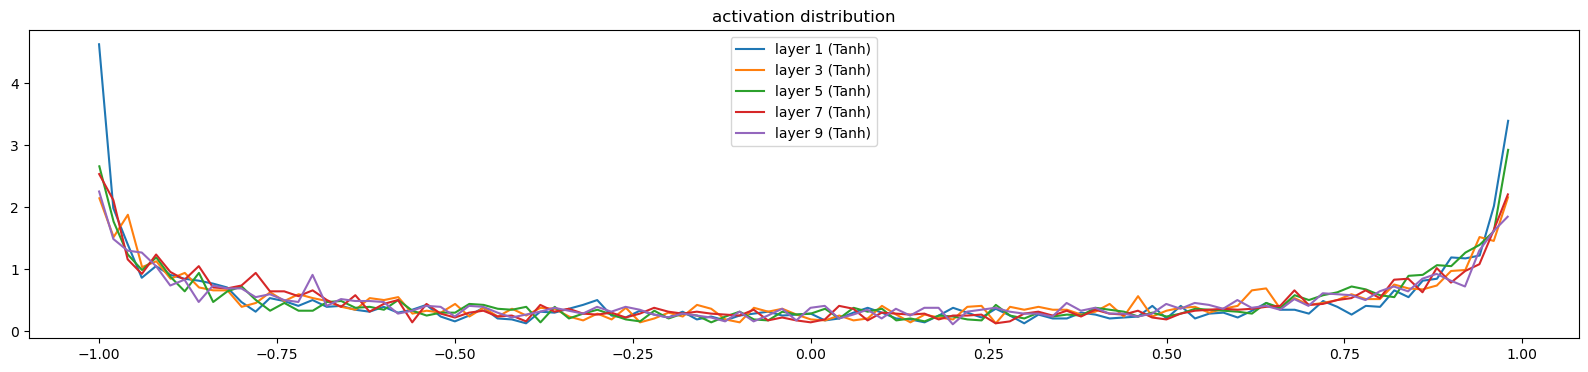

In [44]:
# visualize activations
# play around with different gains other than 5/3
# without batchnorm: you'll notice that with gain 5/3, the saturated % of layer, etc, converges

plt.figure(figsize=(20,4))
legends = []
for i, layer in enumerate(layers[:-1]): # exclude output softmax layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %+.2f, saturated: %+.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('activation distribution')

layer 1 (      Tanh): mean -0.00, std +0.00, saturated: +0.00%
layer 3 (      Tanh): mean -0.00, std +0.00, saturated: +0.00%
layer 5 (      Tanh): mean -0.00, std +0.00, saturated: +0.00%
layer 7 (      Tanh): mean +0.00, std +0.00, saturated: +0.00%
layer 9 (      Tanh): mean +0.00, std +0.00, saturated: +0.00%


Text(0.5, 1.0, 'activation gradient distribution')

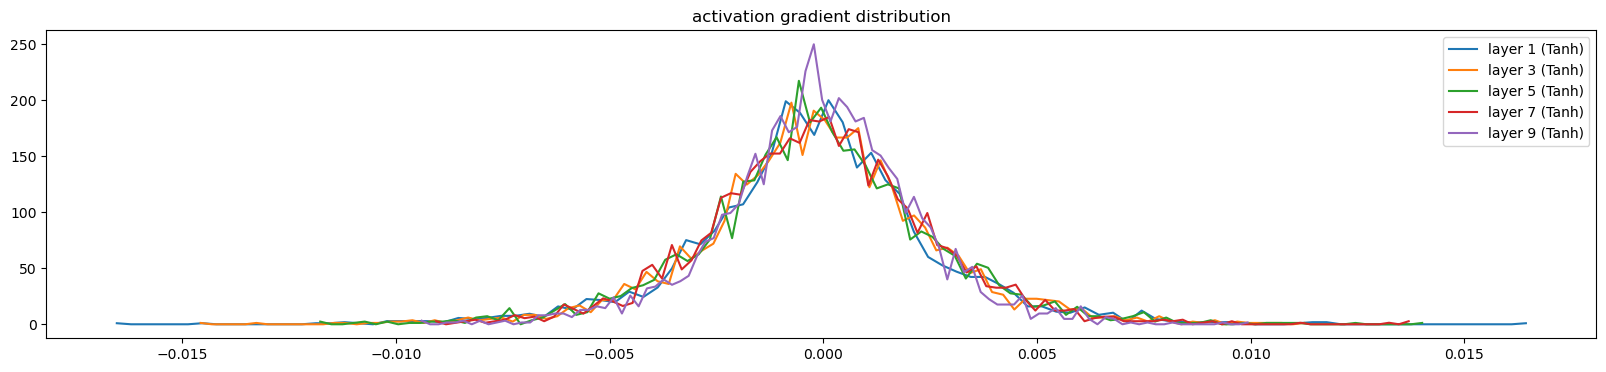

In [45]:
# visualize activation gradients
# we see what we want: all layers' gradients are roughly the same size - dont want them shrinking or exploding

plt.figure(figsize=(20,4))
legends = []
for i, layer in enumerate(layers[:-1]): # exclude output softmax layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+.2f, std %+.2f, saturated: %+.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('activation gradient distribution')

weight   (27, 10) | mean +0.000543 | std 1.210879e-02 | grad:data ratio 1.210873e-02
weight  (30, 100) | mean +0.000091 | std 8.572478e-03 | grad:data ratio 2.741174e-02
weight (100, 100) | mean -0.000079 | std 6.680254e-03 | grad:data ratio 3.974535e-02
weight (100, 100) | mean -0.000033 | std 6.521380e-03 | grad:data ratio 3.846638e-02
weight (100, 100) | mean +0.000037 | std 6.064263e-03 | grad:data ratio 3.592854e-02
weight (100, 100) | mean -0.000092 | std 5.176421e-03 | grad:data ratio 3.075118e-02
weight  (100, 27) | mean +0.000000 | std 2.309357e-02 | grad:data ratio 3.261764e-01


Text(0.5, 1.0, 'weights gradient distribution')

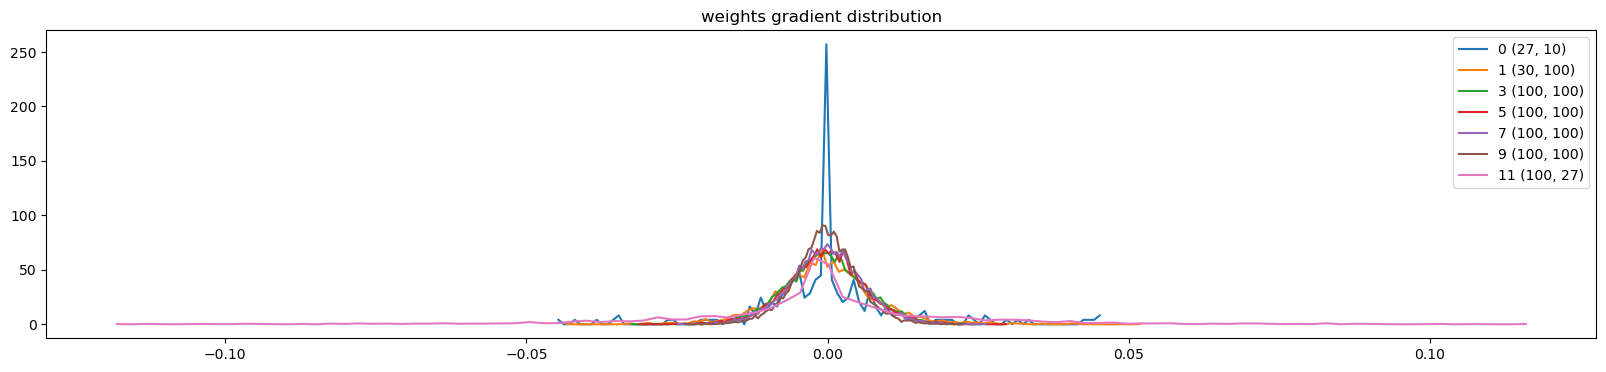

In [48]:
# note grad:data ratio - its a good thing that the grad values are orders of magnitude smaller than data values
# last layer is a little problematic in this regard
# more important than grad:data is update:data ratio

plt.figure(figsize=(20,4))
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution')